In [1]:
pip install pandas requests beautifulsoup4 lxml

Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd

df = pd.read_csv("blackmores.csv")
print(df.columns.tolist())

['element-type-link href', 'absolute src', 'absolute src 2', 'overflow-hidden', 'break-words', 'text-sm', 'font-bold', 'font-bold 2', 'text-sm 2', 'inline']


In [15]:
df_small = df[["break-words", "element-type-link href"]].copy()
df_small["url"] = "https://www.blackmores.com.au" + df_small["element-type-link href"]
print(df_small.head())
print(df_small.shape)

                                break-words  \
0                   Blackmores Ashwagandha+   
1                   Blackmores Beauty Sleep   
2  Blackmores Bilberry Eye Support Advanced   
3                Blackmores Bio ACE Excell®   
4                    Blackmores Bio C® 1000   

                              element-type-link href  \
0  https://www.blackmores.com.au/products/ashwaga...   
1  https://www.blackmores.com.au/products/beauty-...   
2  https://www.blackmores.com.au/products/bilberr...   
3  https://www.blackmores.com.au/products/bio-ace...   
4  https://www.blackmores.com.au/products/bio-c-1000   

                                                 url  
0  https://www.blackmores.com.auhttps://www.black...  
1  https://www.blackmores.com.auhttps://www.black...  
2  https://www.blackmores.com.auhttps://www.black...  
3  https://www.blackmores.com.auhttps://www.black...  
4  https://www.blackmores.com.auhttps://www.black...  
(121, 3)


In [16]:
df_small["url"] = "https://www.blackmores.com.au" + df_small["element-type-link href"]

In [17]:
df_small.head()

,break-words,element-type-link href,url
0,Blackmores Ashwagandha+,https://www.blackmores.com.au/products/ashwaga...,https://www.blackmores.com.auhttps://www.black...
1,Blackmores Beauty Sleep,https://www.blackmores.com.au/products/beauty-...,https://www.blackmores.com.auhttps://www.black...
2,Blackmores Bilberry Eye Support Advanced,https://www.blackmores.com.au/products/bilberr...,https://www.blackmores.com.auhttps://www.black...
3,Blackmores Bio ACE Excell®,https://www.blackmores.com.au/products/bio-ace...,https://www.blackmores.com.auhttps://www.black...
4,Blackmores Bio C® 1000,https://www.blackmores.com.au/products/bio-c-1000,https://www.blackmores.com.auhttps://www.black...


In [18]:
df_small = df[["break-words", "element-type-link href"]].copy()

df_small = df_small.rename(columns={
    "break-words": "product_name",
    "element-type-link href": "url"
})

print(df_small.head())
print(df_small.shape)

                               product_name  \
0                   Blackmores Ashwagandha+   
1                   Blackmores Beauty Sleep   
2  Blackmores Bilberry Eye Support Advanced   
3                Blackmores Bio ACE Excell®   
4                    Blackmores Bio C® 1000   

                                                 url  
0  https://www.blackmores.com.au/products/ashwaga...  
1  https://www.blackmores.com.au/products/beauty-...  
2  https://www.blackmores.com.au/products/bilberr...  
3  https://www.blackmores.com.au/products/bio-ace...  
4  https://www.blackmores.com.au/products/bio-c-1000  
(121, 2)


test for one


In [19]:
import requests
from bs4 import BeautifulSoup

test_url = df_small.loc[0, "url"]
print(test_url)

headers = {
    "User-Agent": "Mozilla/5.0"
}

res = requests.get(test_url, headers=headers)

print("status code:", res.status_code)
print(res.text[:500])

https://www.blackmores.com.au/products/ashwagandha-plus
status code: 200
<!DOCTYPE html><html lang="en-au"><head><meta charSet="utf-8" data-next-head=""/><meta name="viewport" content="width=device-width" data-next-head=""/><title data-next-head="">Blackmores Ashwagandha+ Tablets</title><meta name="description" content="Blackmores Ashwagandha+ with traditional Ayurvedic herb Withania, magnesium and B Vitamins. " data-next-head=""/><link rel="canonical" href="https://www.blackmores.com.au/products/ashwagandha-plus" data-next-head=""/><meta property="og:title" content=


In [20]:
html = res.text.lower()

keywords = [
    "ingredients",
    "active ingredients",
    "contains",
    "each tablet contains",
    "equiv.",
    "mg"
]

for kw in keywords:
    print(kw, "->", kw in html)

ingredients -> True
active ingredients -> True
contains -> True
each tablet contains -> False
equiv. -> False
mg -> True


In [22]:
import re

text = res.text.lower()

def show_mg_context(text, window=80):
    text = re.sub(r'\s+', ' ', text)
    
    for m in re.finditer(r'\d+\.?\d*\s?mg', text):
        start = max(0, m.start() - window)
        end = min(len(text), m.end() + window)
        
        snippet = text[start:end]
        print("\n---")
        print(snippet)

show_mg_context(text)

In [23]:
from bs4 import BeautifulSoup
import json

soup = BeautifulSoup(res.text, "html.parser")

script = soup.find("script", {"id": "__NEXT_DATA__"})

print(script is not None)

True


In [24]:
data = json.loads(script.string)

print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['props', 'page', 'query', 'buildId', 'isFallback', 'isExperimentalCompile', 'gsp', 'locale', 'locales', 'defaultLocale', 'scriptLoader'])


In [25]:
script = soup.find("script", {"id": "__NEXT_DATA__"})
print(script is not None)

True


In [26]:
data = json.loads(script.string)
print(data.keys())

dict_keys(['props', 'page', 'query', 'buildId', 'isFallback', 'isExperimentalCompile', 'gsp', 'locale', 'locales', 'defaultLocale', 'scriptLoader'])


In [27]:
print(data["props"].keys())

dict_keys(['pageProps', '__N_SSG'])


In [28]:
print(data["props"]["pageProps"].keys())

dict_keys(['id', 'productId', 'title', 'locale', 'url', 'alternates', 'seo', 'updatedAt', 'components', 'ingredients', 'faq', 'relatedProductsCompanion', 'byline', 'overview', 'dosage', 'contraindicationsAndCautions', 'prescribingInfo', 'medicineInteractions', 'feedingGuide', 'howToPrepare', 'nutritionalInformation', 'whyUse', 'theBlackmoresDifference', 'servingSuggestion', 'whenToUse', 'disclaimer', 'productSpecification', 'productVariants', 'austl', 'taxonomies', 'dietaryIcons', 'servingType', 'reliefTags', 'brand', 'ingredientContent', 'shopifyProduct', 'lowerBanner', 'persona'])


In [29]:
ingredients = data["props"]["pageProps"]["ingredients"]

print(type(ingredients))
print(ingredients)

<class 'list'>
[{'uid': 'csff0f28f52abbc979', 'ingredientName': 'Active ingredients per tablet:', 'amount': None, 'units': None, 'type': 'Title'}, {'uid': 'cs212ced6945ff967c', 'ingredientName': '<i>Withania somnifera</i> (ashwaganda) extract dry conc.', 'amount': 150, 'units': 'mg', 'type': 'Main'}, {'uid': 'cs8bc9cc2946006b3a', 'ingredientName': 'equivalent dry root', 'amount': 1500, 'units': 'mg (1.5 g)', 'type': 'Supporting'}, {'uid': 'cs3ddcab448423d34f', 'ingredientName': 'standardised to withanolides', 'amount': 4.5, 'units': 'mg', 'type': 'Supporting'}, {'uid': 'cs51392558fcc3a1f5', 'ingredientName': 'Thiamine nitrate (vitamin B1)', 'amount': 12.5, 'units': 'mg', 'type': 'Main'}, {'uid': 'cs549819a2a4e0f128', 'ingredientName': 'Riboflavin (vitamin B2)', 'amount': 12.5, 'units': 'mg', 'type': 'Main'}, {'uid': 'cs77be82ca0a150140', 'ingredientName': 'Nicotinamide', 'amount': 25, 'units': 'mg', 'type': 'Main'}, {'uid': 'cs729e52b961e61277', 'ingredientName': 'Calcium pantothenate'

In [30]:
import pandas as pd

rows = []

for item in ingredients:
    if item["amount"] is not None:
        rows.append({
            "name": item["ingredientName"],
            "amount": item["amount"],
            "unit": item["units"],
            "type": item["type"]
        })

df_ing = pd.DataFrame(rows)

print(df_ing.head())

                                                name  amount        unit  \
0  <i>Withania somnifera</i> (ashwaganda) extract...   150.0          mg   
1                                equivalent dry root  1500.0  mg (1.5 g)   
2                       standardised to withanolides     4.5          mg   
3                      Thiamine nitrate (vitamin B1)    12.5          mg   
4                            Riboflavin (vitamin B2)    12.5          mg   

         type  
0        Main  
1  Supporting  
2  Supporting  
3        Main  
4        Main  


In [31]:
df_ing = pd.DataFrame(rows)
print(df_ing)

                                                 name  amount        unit  \
0   <i>Withania somnifera</i> (ashwaganda) extract...   150.0          mg   
1                                 equivalent dry root  1500.0  mg (1.5 g)   
2                        standardised to withanolides     4.5          mg   
3                       Thiamine nitrate (vitamin B1)    12.5          mg   
4                             Riboflavin (vitamin B2)    12.5          mg   
5                                        Nicotinamide    25.0          mg   
6                                Calcium pantothenate    37.5          mg   
7            equivalent pantothenic acid (vitamin B5)    34.4          mg   
8                            Pyridoxine hydrochloride    25.0          mg   
9                  equivalent pyridoxine (vitamin B6)    20.6          mg   
10                       Cyanocobalamin (vitamin B12)    25.0  micrograms   
11                          Ascorbic acid (vitamin C)    75.0          mg   

In [32]:
import re

def clean_html(text):
    return re.sub(r"<.*?>", "", text)

df_ing["name"] = df_ing["name"].apply(clean_html)

print(df_ing.head())

                                                name  amount        unit  \
0  Withania somnifera (ashwaganda) extract dry conc.   150.0          mg   
1                                equivalent dry root  1500.0  mg (1.5 g)   
2                       standardised to withanolides     4.5          mg   
3                      Thiamine nitrate (vitamin B1)    12.5          mg   
4                            Riboflavin (vitamin B2)    12.5          mg   

         type  
0        Main  
1  Supporting  
2  Supporting  
3        Main  
4        Main  


In [33]:
def convert_to_mg(row):
    if row["unit"] == "micrograms":
        return row["amount"] / 1000
    return row["amount"]

df_ing["amount_mg"] = df_ing.apply(convert_to_mg, axis=1)

print(df_ing[["name", "amount", "unit", "amount_mg"]])

                                                 name  amount        unit  \
0   Withania somnifera (ashwaganda) extract dry conc.   150.0          mg   
1                                 equivalent dry root  1500.0  mg (1.5 g)   
2                        standardised to withanolides     4.5          mg   
3                       Thiamine nitrate (vitamin B1)    12.5          mg   
4                             Riboflavin (vitamin B2)    12.5          mg   
5                                        Nicotinamide    25.0          mg   
6                                Calcium pantothenate    37.5          mg   
7            equivalent pantothenic acid (vitamin B5)    34.4          mg   
8                            Pyridoxine hydrochloride    25.0          mg   
9                  equivalent pyridoxine (vitamin B6)    20.6          mg   
10                       Cyanocobalamin (vitamin B12)    25.0  micrograms   
11                          Ascorbic acid (vitamin C)    75.0          mg   

In [34]:
df_main = df_ing[df_ing["type"] == "Main"].copy()

print(df_main[["name", "amount_mg"]])

                                                 name  amount_mg
0   Withania somnifera (ashwaganda) extract dry conc.   150.0000
3                       Thiamine nitrate (vitamin B1)    12.5000
4                             Riboflavin (vitamin B2)    12.5000
5                                        Nicotinamide    25.0000
6                                Calcium pantothenate    37.5000
8                            Pyridoxine hydrochloride    25.0000
10                       Cyanocobalamin (vitamin B12)     0.0250
11                          Ascorbic acid (vitamin C)    75.0000
12                                             Biotin     0.0375
13                                         Folic acid     0.1500
14                              Heavy magnesium oxide   109.0000
16                            Zinc amino acid chelate    30.0000


In [36]:
rdi_dict = {
    "Thiamine nitrate (vitamin B1)": 1.2,
    "Riboflavin (vitamin B2)": 1.3,
    "Nicotinamide": 16,
    "Calcium pantothenate": 5,
    "Pyridoxine hydrochloride": 1.3,
    "Cyanocobalamin (vitamin B12)": 0.0024,
    "Ascorbic acid (vitamin C)": 90,
    "Biotin": 0.03,
    "Folic acid": 0.4,
    "Zinc amino acid chelate": 11,
}

In [37]:
def get_rdi_score(row):
    name = row["name"]
    if name in rdi_dict:
        return row["amount_mg"] / rdi_dict[name]
    return None

df_main["rdi_score"] = df_main.apply(get_rdi_score, axis=1)

print(df_main[["name", "amount_mg", "rdi_score"]])

                                                 name  amount_mg  rdi_score
0   Withania somnifera (ashwaganda) extract dry conc.   150.0000        NaN
3                       Thiamine nitrate (vitamin B1)    12.5000  10.416667
4                             Riboflavin (vitamin B2)    12.5000   9.615385
5                                        Nicotinamide    25.0000   1.562500
6                                Calcium pantothenate    37.5000   7.500000
8                            Pyridoxine hydrochloride    25.0000  19.230769
10                       Cyanocobalamin (vitamin B12)     0.0250  10.416667
11                          Ascorbic acid (vitamin C)    75.0000   0.833333
12                                             Biotin     0.0375   1.250000
13                                         Folic acid     0.1500   0.375000
14                              Heavy magnesium oxide   109.0000        NaN
16                            Zinc amino acid chelate    30.0000   2.727273


In [38]:
df_main["rdi_score"] = df_main.apply(get_rdi_score, axis=1)
print(df_main)

                                                 name  amount        unit  \
0   Withania somnifera (ashwaganda) extract dry conc.   150.0          mg   
3                       Thiamine nitrate (vitamin B1)    12.5          mg   
4                             Riboflavin (vitamin B2)    12.5          mg   
5                                        Nicotinamide    25.0          mg   
6                                Calcium pantothenate    37.5          mg   
8                            Pyridoxine hydrochloride    25.0          mg   
10                       Cyanocobalamin (vitamin B12)    25.0  micrograms   
11                          Ascorbic acid (vitamin C)    75.0          mg   
12                                             Biotin    37.5  micrograms   
13                                         Folic acid   150.0  micrograms   
14                              Heavy magnesium oxide   109.0          mg   
16                            Zinc amino acid chelate    30.0          mg   

In [39]:
import numpy as np

df_main["score_log"] = np.log1p(df_main["rdi_score"])

print(df_main[["name", "rdi_score", "score_log"]])

                                                 name  rdi_score  score_log
0   Withania somnifera (ashwaganda) extract dry conc.        NaN        NaN
3                       Thiamine nitrate (vitamin B1)  10.416667   2.435074
4                             Riboflavin (vitamin B2)   9.615385   2.362304
5                                        Nicotinamide   1.562500   0.940983
6                                Calcium pantothenate   7.500000   2.140066
8                            Pyridoxine hydrochloride  19.230769   3.007205
10                       Cyanocobalamin (vitamin B12)  10.416667   2.435074
11                          Ascorbic acid (vitamin C)   0.833333   0.606136
12                                             Biotin   1.250000   0.810930
13                                         Folic acid   0.375000   0.318454
14                              Heavy magnesium oxide        NaN        NaN
16                            Zinc amino acid chelate   2.727273   1.315677


In [40]:
total_score = df_main["score_log"].sum()

print("Total Score:", total_score)

Total Score: 16.37190360726406


In [41]:
def score_current_product(df_main):
    total_score = df_main["score_log"].sum()
    return total_score

print(score_current_product(df_main))


16.37190360726406


In [55]:
def ingredients_to_df(ingredients):
    rows = []

    for item in ingredients:
        if item.get("amount") is not None:
            rows.append({
                "name": item.get("ingredientName"),
                "amount": item.get("amount"),
                "unit": item.get("units"),
                "type": item.get("type")
            })

    df_ing = pd.DataFrame(rows, columns=["name", "amount", "unit", "type"])
    return df_ing

In [56]:
def clean_ingredients_df(df_ing):
    import re
    import pandas as pd

    # 如果是空表，直接返回
    if df_ing.empty:
        return pd.DataFrame(columns=["name", "amount", "unit", "type", "amount_mg"])

    # 1. 去 HTML
    df_ing = df_ing.copy()
    df_ing["name"] = df_ing["name"].apply(lambda x: re.sub(r"<.*?>", "", str(x)))

    # 2. 转 mg
    def convert(row):
        if row["unit"] == "micrograms":
            return row["amount"] / 1000
        return row["amount"]

    df_ing["amount_mg"] = df_ing.apply(convert, axis=1)

    # 3. 只保留 Main
    df_main = df_ing[df_ing["type"] == "Main"].copy()

    return df_main

In [49]:
def calculate_score(df_main, rdi_dict):
    import numpy as np
    import pandas as pd

    # 1. RDI score
    def get_rdi(row):
        name = row["name"]
        if name in rdi_dict:
            return row["amount_mg"] / rdi_dict[name]
        return np.nan

    df_main = df_main.copy()
    df_main["rdi_score"] = df_main.apply(get_rdi, axis=1)

    # 2. 只保留有 RDI 的行
    df_main = df_main.dropna(subset=["rdi_score"]).copy()

    # 3. 如果一个产品一个可评分成分都没有
    if df_main.empty:
        return None, df_main

    # 4. log 压缩
    df_main["score_log"] = np.log1p(df_main["rdi_score"].astype(float))

    # 5. 总分
    total_score = df_main["score_log"].sum()

    return total_score, df_main

In [50]:
score, df_scored = calculate_score(df_clean, rdi_dict)

print("Score:", score)
print(df_scored.head())

Score: 16.37190360726406
                            name  amount unit  type  amount_mg  rdi_score  \
3  Thiamine nitrate (vitamin B1)    12.5   mg  Main       12.5  10.416667   
4        Riboflavin (vitamin B2)    12.5   mg  Main       12.5   9.615385   
5                   Nicotinamide    25.0   mg  Main       25.0   1.562500   
6           Calcium pantothenate    37.5   mg  Main       37.5   7.500000   
8       Pyridoxine hydrochloride    25.0   mg  Main       25.0  19.230769   

   score_log  
3   2.435074  
4   2.362304  
5   0.940983  
6   2.140066  
8   3.007205  


In [59]:
import requests
from bs4 import BeautifulSoup
import json

def score_one_product(url, product_name, rdi_dict):
    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    res = requests.get(url, headers=headers, timeout=20)

    if res.status_code != 200:
        return {
            "product_name": product_name,
            "url": url,
            "score": None,
            "status": f"HTTP {res.status_code}"
        }

    soup = BeautifulSoup(res.text, "html.parser")
    script = soup.find("script", {"id": "__NEXT_DATA__"})

    if script is None:
        return {
            "product_name": product_name,
            "url": url,
            "score": None,
            "status": "NO_NEXT_DATA"
        }

    data = json.loads(script.string)
    ingredients = data["props"]["pageProps"]["ingredients"]

    df_ing = ingredients_to_df(ingredients)
    df_clean = clean_ingredients_df(df_ing)

    if df_clean.empty:
        return {
            "product_name": product_name,
            "url": url,
            "score": None,
            "status": "NO_SCORABLE_INGREDIENTS"
        }

    score, df_scored = calculate_score(df_clean, rdi_dict)

    return {
        "product_name": product_name,
        "url": url,
        "score": score,
        "status": "OK"
    }

In [60]:
test_result = score_one_product(
    df_small.loc[0, "url"],
    df_small.loc[0, "product_name"],
    rdi_dict
)

print(test_result)

{'product_name': 'Blackmores Ashwagandha+', 'url': 'https://www.blackmores.com.au/products/ashwagandha-plus', 'score': 16.37190360726406, 'status': 'OK'}


In [61]:
results = []

for i in range(5):
    product_name = df_small.loc[i, "product_name"]
    url = df_small.loc[i, "url"]

    print(f"Scoring {i}: {product_name}")

    result = score_one_product(url, product_name, rdi_dict)
    results.append(result)

results_df = pd.DataFrame(results)
print(results_df)

Scoring 0: Blackmores Ashwagandha+
Scoring 1: Blackmores Beauty Sleep
Scoring 2: Blackmores Bilberry Eye Support Advanced
Scoring 3: Blackmores Bio ACE Excell®
Scoring 4: Blackmores Bio C® 1000
                               product_name  \
0                   Blackmores Ashwagandha+   
1                   Blackmores Beauty Sleep   
2  Blackmores Bilberry Eye Support Advanced   
3                Blackmores Bio ACE Excell®   
4                    Blackmores Bio C® 1000   

                                                 url      score status  
0  https://www.blackmores.com.au/products/ashwaga...  16.371904     OK  
1  https://www.blackmores.com.au/products/beauty-...   0.488353     OK  
2  https://www.blackmores.com.au/products/bilberr...        NaN     OK  
3  https://www.blackmores.com.au/products/bio-ace...  11.227510     OK  
4  https://www.blackmores.com.au/products/bio-c-1000   1.663505     OK  


final test

In [62]:
results = []

for i in range(len(df_small)):
    product_name = df_small.loc[i, "product_name"]
    url = df_small.loc[i, "url"]

    print(f"Scoring {i}: {product_name}")

    result = score_one_product(url, product_name, rdi_dict)
    results.append(result)

results_df = pd.DataFrame(results)

Scoring 0: Blackmores Ashwagandha+
Scoring 1: Blackmores Beauty Sleep
Scoring 2: Blackmores Bilberry Eye Support Advanced
Scoring 3: Blackmores Bio ACE Excell®
Scoring 4: Blackmores Bio C® 1000
Scoring 5: Blackmores Bio C® 500 Chewable
Scoring 6: Blackmores Bio C® 500 Sustained Release
Scoring 7: Blackmores Bio C® Powder
Scoring 8: Blackmores Bio Iron Advanced
Scoring 9: Blackmores Bio Magnesium
Scoring 10: Blackmores Bio Zinc
Scoring 11: Blackmores Calm & Relax
Scoring 12: Blackmores Celery 3000
Scoring 13: Blackmores Cholesterol Health®
Scoring 14: Blackmores Cod Liver Oil 1000mg
Scoring 15: Blackmores Conceive Well Men
Scoring 16: Blackmores Conceive Well™ Gold
Scoring 17: Blackmores Concentrated Curcumin + Active Support
Scoring 18: Blackmores Concentrated Curcumin + Pain Relief
Scoring 19: Blackmores Concentrated Curcumin One-A-Day
Scoring 20: Blackmores CoQ10 150mg
Scoring 21: Blackmores CoQ10 75mg
Scoring 22: Blackmores Cranberry Forte 50,000
Scoring 23: Blackmores Daily Immune 

In [63]:
results_sorted = results_df.sort_values(by="score", ascending=False)

print(results_sorted.head(20))

                                   product_name  \
0                       Blackmores Ashwagandha+   
96                    Blackmores Stress & Sleep   
63                    Blackmores Mega B Complex   
101       Blackmores Superkids™ Multi Chewables   
30        Blackmores Executive B Stress Formula   
90         Blackmores Recovery Magnesium Powder   
16               Blackmores Conceive Well™ Gold   
3                    Blackmores Bio ACE Excell®   
97                    Blackmores Sugar Balance™   
70                Blackmores Nails, Hair & Skin   
10                          Blackmores Bio Zinc   
25              Blackmores Echinacea ACE + Zinc   
8                  Blackmores Bio Iron Advanced   
46                       Blackmores Immune Zinc   
68           Blackmores Multivitamins for Women   
65      Blackmores Multivitamins + Antioxidants   
66             Blackmores Multivitamins for 50+   
67             Blackmores Multivitamins for Men   
112                       Black

In [64]:
print("总产品数:", len(results_df))
print("有分数:", results_df["score"].notna().sum())
print("无分数:", results_df["score"].isna().sum())

总产品数: 121
有分数: 52
无分数: 69


In [65]:
scorable = results_df[results_df["score"].notna()].copy()
scorable_sorted = scorable.sort_values(by="score", ascending=False)

print(scorable_sorted.head(20))

                                   product_name  \
0                       Blackmores Ashwagandha+   
96                    Blackmores Stress & Sleep   
63                    Blackmores Mega B Complex   
101       Blackmores Superkids™ Multi Chewables   
30        Blackmores Executive B Stress Formula   
90         Blackmores Recovery Magnesium Powder   
16               Blackmores Conceive Well™ Gold   
3                    Blackmores Bio ACE Excell®   
97                    Blackmores Sugar Balance™   
70                Blackmores Nails, Hair & Skin   
10                          Blackmores Bio Zinc   
25              Blackmores Echinacea ACE + Zinc   
8                  Blackmores Bio Iron Advanced   
46                       Blackmores Immune Zinc   
68           Blackmores Multivitamins for Women   
65      Blackmores Multivitamins + Antioxidants   
66             Blackmores Multivitamins for 50+   
67             Blackmores Multivitamins for Men   
112                       Black

In [67]:
results_df.to_csv("all_products.csv", index=False)
scorable_sorted.to_csv("ranked_products.csv", index=False)

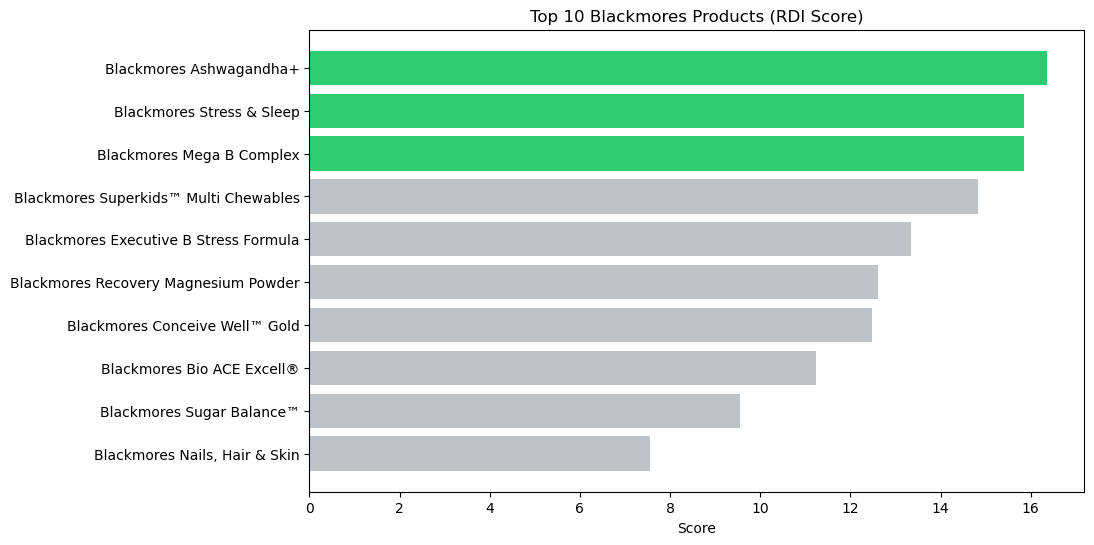

In [71]:
import matplotlib.pyplot as plt

top10 = scorable_sorted.head(10)

# 定义颜色：前3高亮，其余灰色
colors = ['#2ecc71' if i < 3 else '#bdc3c7' for i in range(len(top10))]

plt.figure(figsize=(10,6))
plt.barh(top10["product_name"], top10["score"], color=colors)

plt.gca().invert_yaxis()
plt.title("Top 10 Blackmores Products (RDI Score)")
plt.xlabel("Score")

plt.show()

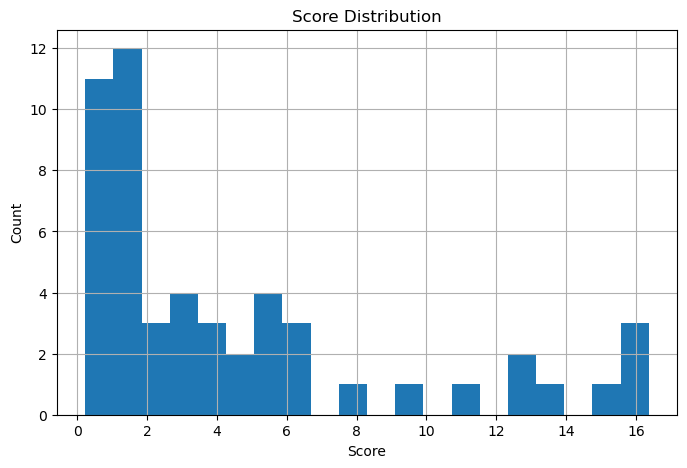

In [69]:
plt.figure(figsize=(8,5))
scorable["score"].hist(bins=20)
plt.title("Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

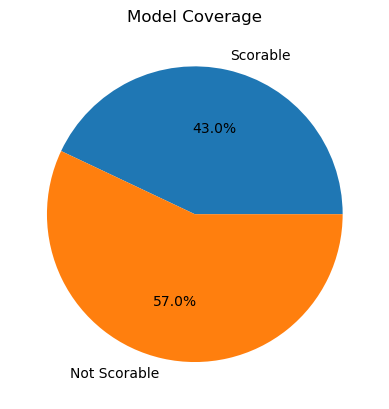

In [70]:
labels = ["Scorable", "Not Scorable"]
sizes = [
    results_df["score"].notna().sum(),
    results_df["score"].isna().sum()
]

plt.pie(sizes, labels=labels, autopct="%1.1f%%")
plt.title("Model Coverage")
plt.show()

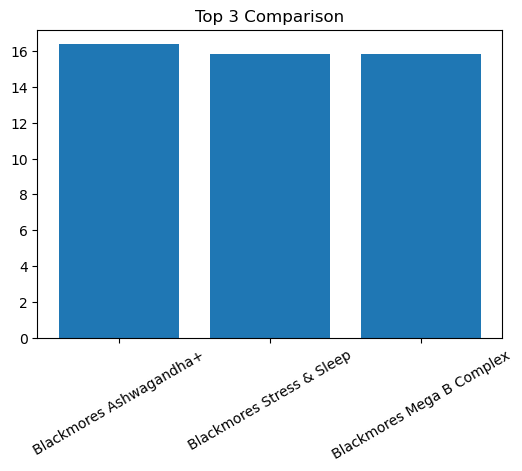

In [74]:
top3 = scorable_sorted.head(3)

plt.figure(figsize=(6,4))
plt.bar(top3["product_name"], top3["score"])
plt.xticks(rotation=30)
plt.title("Top 3 Comparison")
plt.show()

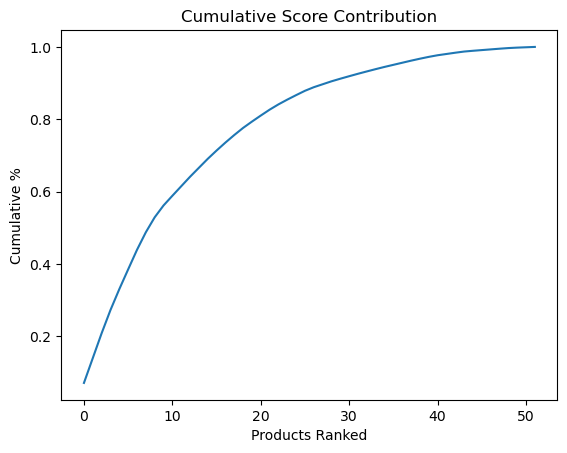

In [75]:
sorted_scores = scorable_sorted["score"].values
cum = sorted_scores.cumsum() / sorted_scores.sum()

plt.plot(cum)
plt.title("Cumulative Score Contribution")
plt.xlabel("Products Ranked")
plt.ylabel("Cumulative %")
plt.show()